# 03 · EDA — Ocupacion turistica

`gold.ocupacion_turistica` — ocupacion de plazas (%) mensual por municipio y tipo de alojamiento (hotelera / apartamentos). Fuente: IBESTAT. Feature candidata: ocupacion media anual por municipio.


In [1]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(60)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)
DATA = Path("data")


In [2]:
df = pl.read_csv(DATA / "ocupacion_turistica.csv", infer_schema_length=None)
print("shape:", df.shape)
print("tipos:", sorted(df["tipo_alojamiento"].unique().to_list()))
df.head(5)


shape: (5385, 8)
tipos: ['apartamentos', 'hotelera']


cod_provincia_ine,nombre_provincia,cod_municipio_ine,nombre_municipio,anio,mes,tipo_alojamiento,ocupacion_plazas_pct
i64,str,i64,str,i64,i64,str,f64
72,"""Eivissa""",7054,"""Santa Eulària des Riu""",2025,10,"""apartamentos""",0.464
71,"""Formentera""",7024,"""Formentera""",2025,10,"""apartamentos""",0.4354
73,"""Mallorca""",7003,"""Alcúdia""",2025,9,"""apartamentos""",0.7557
73,"""Mallorca""",7011,"""Calvià""",2025,9,"""apartamentos""",0.6755
73,"""Mallorca""",7040,"""Palma""",2025,9,"""apartamentos""",0.6161


In [3]:
print("Nulos por columna:")
df.null_count()


Nulos por columna:


cod_provincia_ine,nombre_provincia,cod_municipio_ine,nombre_municipio,anio,mes,tipo_alojamiento,ocupacion_plazas_pct
u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0


In [4]:
# Cobertura: municipios con datos y rango temporal
print("municipios con datos turisticos:", df["cod_municipio_ine"].n_unique())
print("anios:", df["anio"].min(), "..", df["anio"].max())
df.group_by("cod_municipio_ine").agg(anio_min=pl.col("anio").min(), anio_max=pl.col("anio").max(), n=pl.len()).sort("n")


municipios con datos turisticos: 26
anios: 2008 .. 2026


cod_municipio_ine,anio_min,anio_max,n
i64,i64,i64,u32
7002,2008,2025,95
7050,2008,2024,97
7033,2008,2026,127
7005,2008,2026,128
7059,2008,2026,131
7055,2008,2026,135
7039,2008,2026,135
7031,2008,2026,135
7014,2008,2026,151


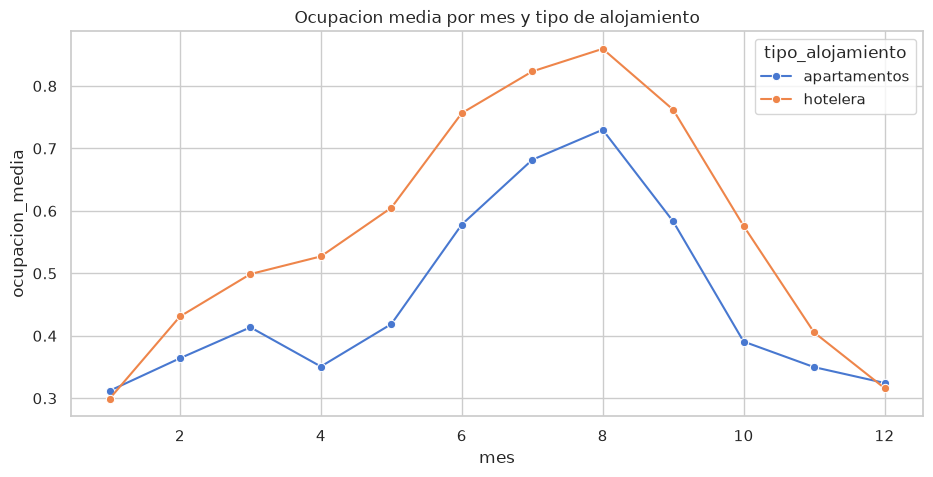

In [5]:
# Estacionalidad por tipo de alojamiento
mes_tipo = df.group_by(["tipo_alojamiento", "mes"]).agg(pl.col("ocupacion_plazas_pct").mean().alias("ocupacion_media"))
sns.lineplot(data=mes_tipo.to_pandas(), x="mes", y="ocupacion_media", hue="tipo_alojamiento", marker="o")
plt.title("Ocupacion media por mes y tipo de alojamiento")
plt.show()


In [6]:
# Feature anual por municipio: ocupacion media (ambos tipos juntos)
anual_mun = df.group_by(["cod_municipio_ine", "anio"]).agg(
    pl.col("ocupacion_plazas_pct").mean().alias("ocupacion_media")
)
ultimo = anual_mun["anio"].max()
ranking = anual_mun.filter(pl.col("anio") == ultimo).sort("ocupacion_media", descending=True)
ranking.head(10)

# Municipios SIN datos turisticos (41 de 67)
mun = pl.read_csv(DATA / "municipio.csv", infer_schema_length=None)
sin_datos = mun.filter(~pl.col("cod_municipio").is_in(anual_mun["cod_municipio_ine"].to_list()))
print(f"municipios sin datos turisticos: {sin_datos.height} de {mun.height}")
print("-> imputacion en el modelo: ocupacion_media = 0 (sin plazas turisticas)")


municipios sin datos turisticos: 41 de 67
-> imputacion en el modelo: ocupacion_media = 0 (sin plazas turisticas)


**Conclusiones EDA**

- 26 de 67 municipios tienen datos (2008-2026, mensual); los 41 restantes no tienen infraestructura turistica censada.
- Estacionalidad muy marcada (verano), mas en hotelera.
- Feature: `ocupacion_media` anual por municipio; imputar **0** a los municipios sin datos (+ columna flag `tiene_turismo`).
